In [1]:
pip install roboflow opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
###  Шаг 1: Конвертация DICOM --> JPG

# Суть кода: Нейросети не понимают сырые КТ-снимки. Этот код применяет фильтр контрастности (HU Windowing) и переводит `.dcm` файлы в легкие `.jpg`.

# Что нужно сделать:
#1. Запустите ячейку (`Shift + Enter`).
#2. В появившемся поле **вставьте путь к папке** с вашими `.dcm` файлами и нажмите **Enter**.
#3. Дождитесь окончания обработки.

In [7]:
import pydicom
import cv2
import numpy as np
import os

#  Настройка путей: Исходная папка с DICOM и папка для сохранения JPG
dicom_folder_path = r"C:\Users\alper\OneDrive\Masaüstü\Liver-Segmentation-3D-Reconstruction\sample_data\abd_arter_5"
output_folder_path = r"C:\New_Data_JPG"

# Проверка и создание выходной папки
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)

# Сортировка файлов для сохранения порядка срезов (Z-ось)
dicom_files = sorted([f for f in os.listdir(dicom_folder_path) if f.lower().endswith('.dcm')])

print(f" Найдено {len(dicom_files)} медицинских срезов. Начало обработки...\n")

success_count = 0

for idx, file_name in enumerate(dicom_files):
    try:
        dicom_path = os.path.join(dicom_folder_path, file_name)
        ds = pydicom.dcmread(dicom_path)
        
        # Перевод пикселей в единицы Хаунсфилда (HU)
        hu_image = ds.pixel_array * ds.RescaleSlope + ds.RescaleIntercept
        
        # Настройка медицинского окна (Windowing) для контрастности
        window_center = 40
        window_width = 150
        min_hu = window_center - (window_width / 2)
        max_hu = window_center + (window_width / 2)
        
        # Нормализация в диапазон [0, 255]
        windowed = np.clip(hu_image, min_hu, max_hu)
        normalized = ((windowed - min_hu) / (max_hu - min_hu) * 255).astype(np.uint8)
        
        # Сохранение среза в формате JPG (Английское название файла)
        jpg_name = f"slice_{idx:03d}.jpg"
        jpg_path = os.path.join(output_folder_path, jpg_name)
        
        cv2.imwrite(jpg_path, normalized)
        success_count += 1
        
        # Лог прогресса каждые 100 файлов
        if success_count % 100 == 0:
            print(f" {success_count}/{len(dicom_files)} slices converted...")
            
    except Exception as e:
        print(f" Error in file {file_name}: {e}")

print("\n" + "="*50)
print(f" PROCESSING COMPLETE! Successfully converted {success_count} slices.")
print(f" Output folder: {output_folder_path}")
print("="*50)

 Найдено 665 медицинских срезов. Начало обработки...

 100/665 slices converted...
 200/665 slices converted...
 300/665 slices converted...
 400/665 slices converted...
 500/665 slices converted...
 600/665 slices converted...

 PROCESSING COMPLETE! Successfully converted 665 slices.
 Output folder: C:\New_Data_JPG


In [ ]:
###  Шаг 2: Сегментация печени (2D Inference)

#Суть кода: Нейросеть (Roboflow) анализирует `.jpg` срез, находит контуры печени и отрисовывает полигональную маску.

# Что нужно сделать:
#1. Запустите ячейку (`Shift + Enter`).
#2. В появившемся поле введите **zH52UCa8FWRNqHiSCd63**.
#3. Введите путь к тестовому `.jpg` снимку.#

loading Roboflow workspace...
loading Roboflow project...
 Модель работает, поиск печени (Inference)...
 Обработка завершена! Результат:


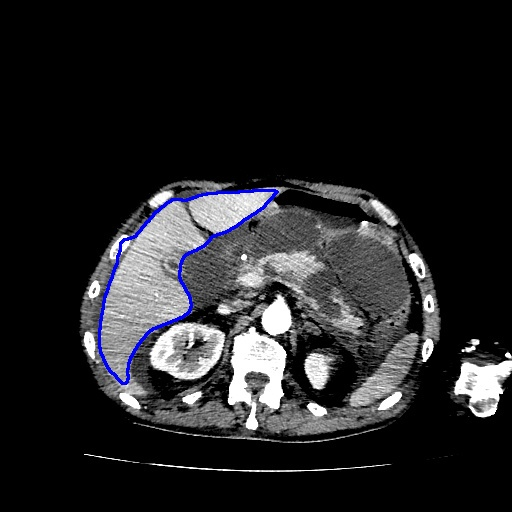

In [ ]:
from roboflow import Roboflow
from IPython.display import Image, display

#  Настройка API: Запрос ключа у пользователя (Безопасный метод)
rf = Roboflow(api_key="zH52UCa8FWRNqHiSCd63")


# Инициализация проекта и модели (Версия 2)
project = rf.workspace("alper-guzel").project("liver-dicom-finetune")
model = project.version(2).model 

# Путь к тестовому изображению
image_path = r"C:\New_Data_JPG\slice_200.jpg" #Можно заменить на любой другой JPG из папки
print(" Модель работает, поиск печени (Inference)...")

# Выполнение предсказания и сохранение результата
prediction = model.predict(image_path, confidence=40)
output_filename = "predicted_liver.jpg"
prediction.save(output_filename)

print(" Обработка завершена! Результат:")

# Вывод результата на экран
display(Image(filename=output_filename))

In [3]:
!pip install scikit-image trimesh opencv-python numpy

In [4]:
!pip install trimesh

In [ ]:
###  Шаг 3: 3D-Реконструкция и Фильтрация (Генерация STL)

#Суть кода: Этот финальный блок собирает все 2D-маски в единый 3D-объем (Voxel Volume). С помощью алгоритма Marching Cubes, сжатия по оси Z для корректировки толщины КТ-среза и фильтрации шумов, система автоматически создает готовую к печати `.stl` модель печени. В код встроен механизм `Retry` для защиты от разрывов соединения.

# Что нужно сделать:
#1. Запустите ячейку (`Shift + Enter`).
#2. Введите  **Roboflow API ключ** (в целях безопасности он не хранится в коде).
#3. Укажите путь к папке с обработанными `.jpg` снимками.
#4. Дождитесь завершения процесса и заберите готовый файл `Final_Realistic_Liver.stl`.

In [11]:
import os
import cv2
import numpy as np
import trimesh
import time
from skimage import measure
from roboflow import Roboflow

#                      - НАСТРОЙКИ -
Z_SPACING = 0.3            # Сжатие по оси Z для коррекции пропорций КТ
MIN_AREA = 1500            # Фильтр шумов: удаление объектов меньше 1500 пикселей
CONFIDENCE_THRESHOLD = 60  # Порог уверенности модели (игнорирует ложные срабатывания)
# --------------------------------------------------------------------------

# 1. Настройка API и подключение к проекту
rf = Roboflow(api_key="zH52UCa8FWRNqHiSCd63")

project = rf.workspace("alper-guzel").project("liver-dicom-finetune")
model = project.version(2).model

# 2. Папка с обработанными JPG снимками
input_folder_path = r"C:\New_Data_JPG"

image_files = sorted([f for f in os.listdir(input_folder_path) if f.lower().endswith('.jpg')])
volume_masks = []

print(f" Total {len(image_files)} slices will be processed. Starting pipeline...\n")

# 3. Цикл обработки каждого снимка через нейросеть
for file_name in image_files:
    image_path = os.path.join(input_folder_path, file_name)
    
    img = cv2.imread(image_path)
    if img is None:
        continue
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    # --- ЗАЩИТНЫЙ БЛОК: Повторная попытка при сбое сети (Retry Mechanism) ---
    is_success = False
    retry_count = 0
    
    while not is_success and retry_count < 5:
        try:
            prediction = model.predict(image_path, confidence=CONFIDENCE_THRESHOLD)
            prediction_data = prediction.json()
            is_success = True
        except Exception as e:
            retry_count += 1
            print(f" Connection error, waiting 3 seconds... (Retry {retry_count}/5) - File: {file_name}")
            time.sleep(3)
            
    if not is_success:
        print(f"  ERROR: {file_name} skipped, server not responding.")
        volume_masks.append(mask)
        continue
    # --------------------------------------------------

    # 4. Если модель нашла печень, создаем маску
    if "predictions" in prediction_data and len(prediction_data["predictions"]) > 0:
        for pred in prediction_data["predictions"]:
            if "points" in pred:
                points = np.array([[p['x'], p['y']] for p in pred['points']], np.int32)
                
                # --- НОВОВВЕДЕНИЕ: ФИЛЬТР ПЛОЩАДИ (Очистка шума) ---
                area = cv2.contourArea(points)
                if area > MIN_AREA: 
                    cv2.fillPoly(mask, [points], 255)
    
    volume_masks.append(mask)
    print(f" Processed & Filtered: {file_name}")

print("\nAll slices processed. Initiating 3D Reconstruction...")

# 5. Преобразование списка масок в 3D матрицу (Voxel Volume)
volume_3d = np.array(volume_masks)

# 6. Алгоритм Marching Cubes с применением Z-сжатия
try:
    # Параметр spacing: (Z_scale, Y_scale, X_scale)
    verts, faces, normals, values = measure.marching_cubes(volume_3d, level=127, spacing=(Z_SPACING, 1.0, 1.0))
    mesh = trimesh.Trimesh(vertices=verts, faces=faces)
    
    output_mesh_name = "Final_Realistic_Liver.stl"
    mesh.export(output_mesh_name)
    print(f"\n  '{output_mesh_name}' has been successfully generated and saved!")

except ValueError:
    print("\n ERROR: Model found no liver in any slices. Confidence threshold might be too high.")

loading Roboflow workspace...
loading Roboflow project...
 Total 665 slices will be processed. Starting pipeline...

 Processed & Filtered: slice_000.jpg
 Processed & Filtered: slice_001.jpg
 Processed & Filtered: slice_002.jpg
 Processed & Filtered: slice_003.jpg
 Processed & Filtered: slice_004.jpg
 Processed & Filtered: slice_005.jpg
 Processed & Filtered: slice_006.jpg
 Processed & Filtered: slice_007.jpg
 Processed & Filtered: slice_008.jpg
 Processed & Filtered: slice_009.jpg
 Processed & Filtered: slice_010.jpg
 Processed & Filtered: slice_011.jpg
 Processed & Filtered: slice_012.jpg
 Processed & Filtered: slice_013.jpg
 Processed & Filtered: slice_014.jpg
 Processed & Filtered: slice_015.jpg
 Processed & Filtered: slice_016.jpg
 Processed & Filtered: slice_017.jpg
 Processed & Filtered: slice_018.jpg
 Processed & Filtered: slice_019.jpg
 Processed & Filtered: slice_020.jpg
 Processed & Filtered: slice_021.jpg
 Processed & Filtered: slice_022.jpg
 Processed & Filtered: slice_023